## Recency Frequency Monetary (RFM) Analysis using KMeans Clustering from the year 2020 to 2023
### Introduction: Customer Segmentation using RFM Analysis
RFM (Recency, Frequency, Monetary) analysis is a marketing technique used to determine quantitatively which customers are the best ones by examining how recently a customer has purchased (recency), how often they purchase (frequency), and how much the customer spends (monetary).

All imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
import plotly as py 
import sys
from datetime import datetime, timedelta
from sklearn.cluster import KMeans
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.discriminant_analysis import StandardScaler
import warnings
from scipy import stats
from scipy.spatial.distance import cdist
warnings.filterwarnings("ignore")

Input the location of the dataset to run the folder

In [2]:
path = '../Data/Intuilize_MNSU_SampleSales_V1_011524 - Intuilize_SampleSales_V1_011524.csv'

### 1. Exploratory Data Analysis

Read in the data

In [3]:
df = pd.read_csv(path)
df.head()

,LocationID,LocationName,BranchID,BranchName,InvoiceNumber,ProductGroup,ProductCode,CustomerName,CustomerCode,SalesDate,ExtCost,ExtPrice,SalesQty,UnitCost,UnitPrice,GM%
0,1,Dallas,1,ACME Inc,1320612,Electrical,AAA88,Dickinson-Fay,17314,8/11/2021,"$1,685.15","$2,286.99",10.0,$168.5150,$228.6989,26.32
1,1,Dallas,1,ACME Inc,1320619,Electrical,AAA9A,Grimes-Grimes,17373,8/11/2021,$52.74,$90.15,10.0,$5.2743,$9.0149,41.49
2,1,Dallas,1,ACME Inc,1320621,Electrical,AA459,Goyette-Legros,18145,8/11/2021,$41.31,$59.02,1.0,$41.3138,$59.0197,30.00
3,1,Dallas,1,ACME Inc,1320621,Electrical,AA567,Goyette-Legros,18145,8/11/2021,$8.78,$13.46,1.0,$8.7770,$13.4642,34.81
4,1,Dallas,1,ACME Inc,1320622,Electrical,AA570,Lockman-Prosacco,12908,8/11/2021,$49.97,$64.62,2.0,$24.9847,$32.3090,22.67


Statistical Description of the data

In [5]:
df.describe()

,LocationID,BranchID,InvoiceNumber,CustomerCode,SalesQty,GM%
count,519560.000000,519560.000000,5.195600e+05,519560.000000,5.195600e+05,5.195600e+05
mean,1.503647,1.503647,9.516042e+06,15366.987822,1.185154e+03,1.388611e+01
std,0.499987,0.499987,1.067662e+07,1715.213382,1.145823e+04,4.846815e+03
min,1.000000,1.000000,1.300431e+06,12346.000000,2.200000e-01,-3.055478e+06
25%,1.000000,1.000000,1.374400e+06,13658.000000,3.000000e+00,2.397000e+01
50%,2.000000,2.000000,5.828237e+06,15514.000000,1.600000e+01,3.000000e+01
75%,2.000000,2.000000,6.059953e+06,17007.000000,1.450000e+02,3.807000e+01
max,2.000000,2.000000,3.042252e+07,18283.000000,1.267776e+06,1.000000e+02


Checking the total number of transactions, products and customers

In [6]:
pd.DataFrame([{'products': len(df['ProductCode'].value_counts()), 'transactions': len(df['InvoiceNumber'].value_counts()), 'customers': len(df['CustomerCode'].value_counts())}], columns=['products', 'transactions', 'customers'], index=['quantity'])

,products,transactions,customers
quantity,61022,152813,2408


Removing the preceding '$' from the data and converting it to float
Converting the date to datetime objects

In [4]:
'''
Removes any $ occurinng in the columns
'''
def cleanCurrency(df, columns):
    for col in columns:
        df[col] = df[col].replace('[\$,]', '', regex=True).astype(float)

'''
Converts the columns to date time
'''  
def cleanDate(df, columns):
    for col in columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    
cleanCurrency(df, ['ExtPrice', 'ExtCost', 'UnitCost', 'UnitPrice'])
cleanDate(df, ['SalesDate'])

Checking the start and end date of the data

In [5]:
print('Start date: {}'.format(df['SalesDate'].min()))
print('End date: {}'.format(df['SalesDate'].max()))

Start date: 2020-09-25 00:00:00
End date: 2023-12-31 00:00:00


Creating a RFM table

In [6]:
'''
Create a new RFM DataFrame with the necessary columns
'''
def createRFMDataFrame(df):
    # Create a new dataframe with the necessary columns
    rfm = df.groupby('CustomerCode').agg({'SalesDate': lambda date: (df['SalesDate'].max() - date.max()).days,
                                         'InvoiceNumber': lambda num: len(num),
                                         'ExtPrice': lambda price: price.sum()})

    # Convert the SalesDate to int
    rfm['SalesDate'] = rfm['SalesDate'].astype(int)

    # Rename the columns
    rfm.rename(columns={'SalesDate': 'Recency', 
                        'InvoiceNumber': 'Frequency', 
                        'ExtPrice': 'Monetary'}, inplace=True)

    return rfm

rfm = createRFMDataFrame(df)
rfm.head()
# Adding 1 to the zeroes to avoid issues with log transformation
rfm['Recency'] = rfm['Recency'].apply(lambda x: x+1)

In [7]:
rfm.head()

,Recency,Frequency,Monetary
CustomerCode,,,
12346,92,3,7535.10
12347,537,2,3017.45
12348,9,102,755281.56
12350,12,300,38223.76
12352,2,78,9454.96


Visualizing the RFM table and exploring the distribution of the RFM values  

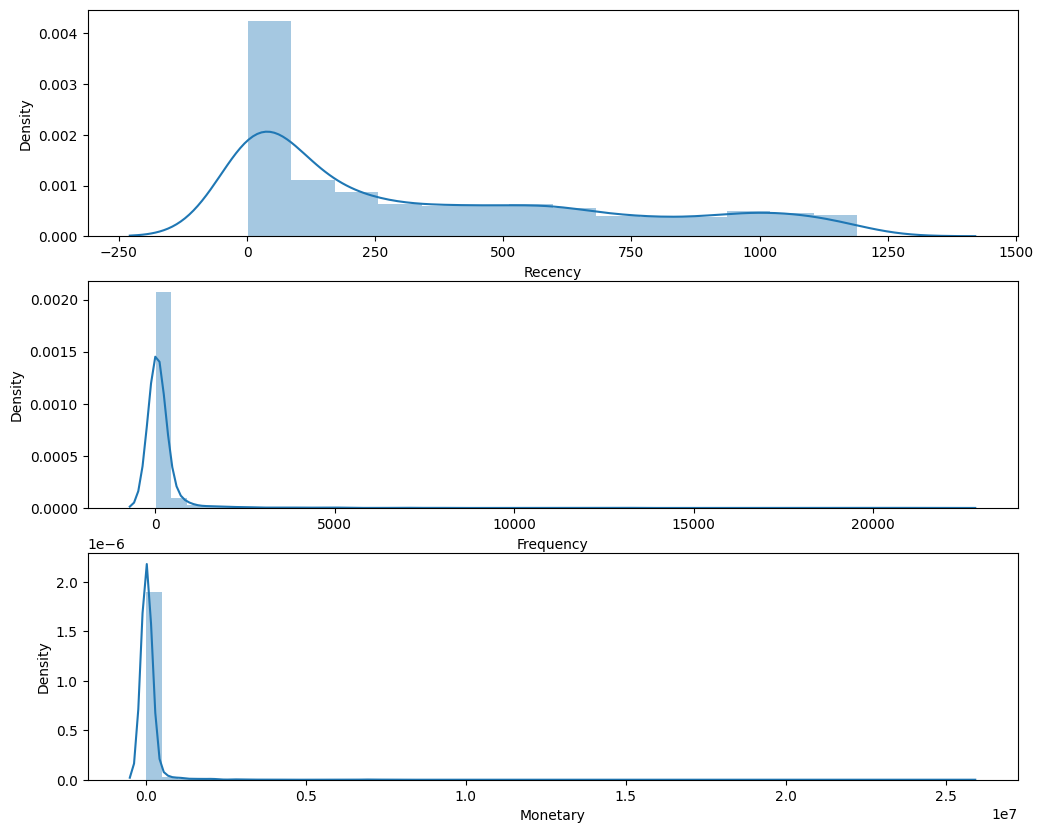

In [13]:
def visualizeDistribution(df, columns):
    '''
    Visualize the distribution of the RFM variables.
    '''
    plt.figure(figsize=(12, 10))
    for i, col in enumerate(columns):
        plt.subplot(3, 1, i+1)
        sns.distplot(df[col])
    plt.show()

visualizeDistribution(rfm, ['Recency', 'Frequency', 'Monetary'])

Visualize and analyze the skewness of the RFM values

In [14]:
def analyze_skewness(x):
    '''
    Visualize the skewness of the RFM variables.
    '''
    fig, ax = plt.subplots(2, 2, figsize=(10, 5))
    sns.distplot(rfm[x], ax=ax[0,0])
    sns.distplot(np.log(rfm[x]), ax=ax[0,1])  # Change displot to histplot for univariate distributions
    sns.distplot(np.sqrt(rfm[x]), ax=ax[1,0])  # Change displot to histplot for univariate distributions
    sns.distplot(stats.boxcox(rfm[x])[0], ax=ax[1,1])  # Change displot to histplot for univariate distributions
    plt.tight_layout()
    plt.show()

    print('Log Transform: The skew coefficient of', rfm[x].skew().round(2), 'is reduced to', np.log(rfm[x]).skew().round(2))
    print('Square Root Transform: The skew coefficient of', rfm[x].skew().round(2), 'is reduced to', np.sqrt(rfm[x]).skew().round(2))
    print('Box Cox Transform: The skew coefficient of', rfm[x].skew().round(2), 'is reduced to', pd.Series(stats.boxcox(rfm[x])[0]).skew().round(2))

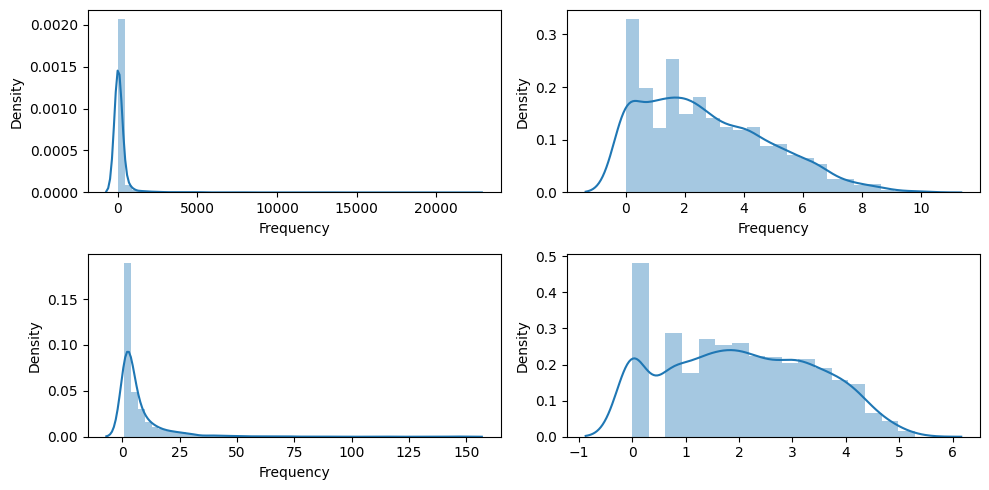

Log Transform: The skew coefficient of 13.27 is reduced to 0.63
Square Root Transform: The skew coefficient of 13.27 is reduced to 4.95
Box Cox Transform: The skew coefficient of 13.27 is reduced to 0.1


In [10]:
# Replace with any of the labels: Recency, Frequency, Monetary
analyze_skewness('Frequency')

## 2. Data Preprocessing and Transformation.

Using box cox transformation to reduce the skewness of the RFM values

In [16]:
def fix_skewness(df, columns):
    """
    Fix skewness in specified columns of a DataFrame using Box-Cox transformation.

    Parameters:
    - df: DataFrame: Input DataFrame
    - columns: list of str: List of column names to fix skewness

    Returns:
    - df_fixed: DataFrame: DataFrame with skewness fixed in specified columns
    """
    df_fixed = pd.DataFrame()
    for column in columns:
        df_fixed[column] = stats.boxcox(df[column])[0]
    return df_fixed

# Example usage:
rfm_columns = ['Recency', 'Frequency', 'Monetary']
customers_fix = fix_skewness(rfm, rfm_columns)
customers_fix.tail()

,Recency,Frequency,Monetary
2403,14.425057,0.659584,4.138178
2404,12.675106,1.015893,5.221679
2405,16.933552,0.000000,5.712618
2406,15.524461,1.696400,4.592656
2407,15.449071,1.882744,7.631539


Normalizing the RFM values

In [17]:
def scaleData(data):
    '''
    Normalize the data and round the mean to two decimal places.
    '''
    scaler = StandardScaler()
    scaler.fit(data)
    scaler.transform(data)
    return scaler.transform(data)
customer_normalized = scaleData(customers_fix)
print(customer_normalized.mean(axis = 0).round(2))
print(customer_normalized.std(axis = 0).round(2))

[-0.  0. -0.]
[1. 1. 1.]


Elbow method to find the optimal number of clusters

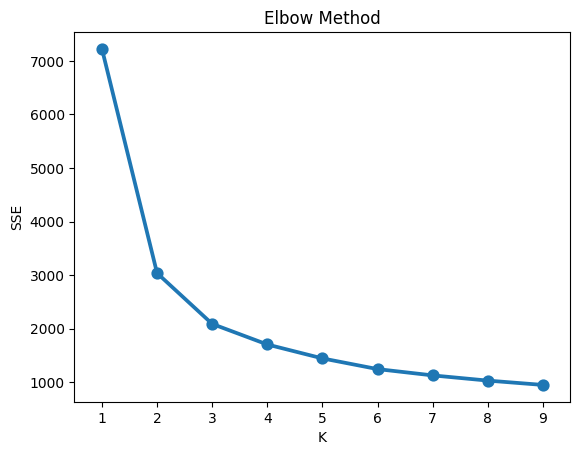

In [16]:
def elbowMethod(data):
    '''
    The Elbow Method is a technique used to determine the optimal number of clusters in a dataset.
    '''
    distortions = []
    K = range(1, 10)
    inertias = []
    mapping1 = {}
    sse = {}
    for k in K:
        # Building and fitting the model
        kmeanModel = KMeans(n_clusters=k).fit(data)
        kmeanModel.fit(data)
        distortions.append(sum(np.min(cdist(data, kmeanModel.cluster_centers_, 'euclidean'), axis=1)) / data.shape[0])
        inertias.append(kmeanModel.inertia_)
        mapping1[k] = sum(np.min(cdist(data, kmeanModel.cluster_centers_, 'euclidean'), axis=1)) / data.shape[0]
        sse[k] = kmeanModel.inertia_
    plt.title('Elbow Method')
    plt.xlabel('K')
    plt.ylabel('SSE')
    sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
    plt.show()

elbowMethod(customer_normalized)

## 3. Modeling the Data with Kmeans Clustering

Fit the data into KMeans clustering model,

In [17]:
def kmeansModel(data, clusters):
    '''
    Create a KMeans model with the specified number of clusters.
    '''
    kmeans = KMeans(n_clusters=clusters, random_state=42)
    kmeans.fit(data)
    return kmeans
model = kmeansModel(customer_normalized, 4)
model.labels_.shape
rfm['Cluster'] = model.labels_
rfm.head()
# Group the data by cluster and aggregate them by their mean
rfm.groupby('Cluster').agg({'Recency': 'mean', 'Frequency': 'mean', 'Monetary': 'mean'}).round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,79.45,15.45,4093.74
1,684.50,2.48,417.28
2,507.31,38.18,15411.38
3,27.98,766.08,381653.72


## 4. Visualizing the clusters

Exploring the clusters and their visualizations

In [18]:
# Creating a new dataframe to help with the visualization.
df_normalized = pd.DataFrame(customer_normalized, columns=customers_fix.columns)
df_normalized['ID'] = rfm.index
df_normalized['Cluster'] = ['Bronze' if label == 0 else 'Silver' if label == 1 else 'Gold' if label == 2 else 'Platinum' for label in model.labels_]
df_normalized.head()

# Melts the Recency, Frequency and Monetary values into a single column for easier visualization.
columns = ['Recency', 'Frequency', 'Monetary']
def meltData(data, columns):
    return pd.melt(data, id_vars=['ID', 'Cluster'], value_vars=columns, var_name='Attribute', value_name='Value')
df_normalized_melted = meltData(df_normalized, columns)


# Count the number of clusters(Aggregate) and find the percentage of customers in each cluster
fig3 = df_normalized_melted.groupby('Cluster').agg({'ID': lambda x : len(x)}).reset_index()

fig3.rename(columns={'ID': 'Number of Count'}, inplace=True)
fig3['percent'] = fig3['Number of Count']/fig3['Number of Count'].sum()*100
fig3['percent'] = fig3['percent'].round(2)
fig3.head()

,Cluster,Number of Count,percent
0,Bronze,1347,18.65
1,Gold,1602,22.18
2,Platinum,1920,26.58
3,Silver,2355,32.60


Cluster Distribution across the dataset

In [21]:
# Visualize the distribution of the clusters
colors = ['gold', 'silver', 'lightblue', 'green']
fig = px.treemap(fig3, path=['Cluster'], values='Number of Count',width=800, height=400, title='Distribution of Cluster')
fig.update_layout(treemapcolorway=colors, margin=dict(t=50, l=25, r=25, b=25))
fig.data[0].textinfo = 'label+text+value+percent root'
fig.show()

Snake plot to see the distribution of recency, frequency and monetary values of the four clusters. Since they separate from each other it means that the clusters are well defined.

<Axes: xlabel='Attribute', ylabel='Value'>

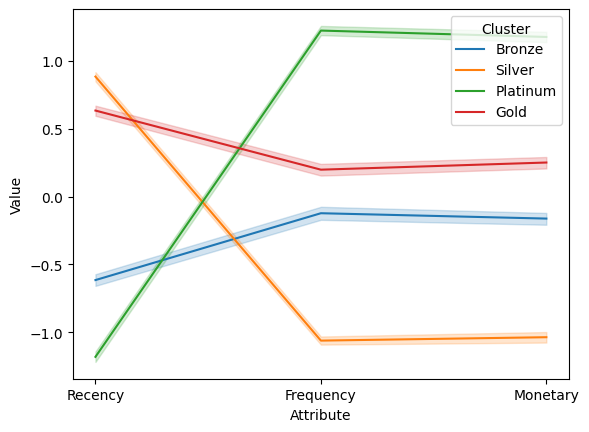

In [22]:
sns.lineplot(x='Attribute', y='Value', hue='Cluster', data=df_normalized_melted)

In [23]:
# Mean of the clusters on each attribute
rfm.groupby('Cluster').agg({'Recency': 'mean', 'Frequency': 'mean', 'Monetary': ['mean','count']}).round(2)

Recency Frequency   Monetary      
           mean      mean       mean count
Cluster                                   
0         79.45     15.45    4093.74   449
1        684.50      2.48     417.28   785
2        507.31     38.18   15411.38   534
3         27.98    766.08  381653.72   640

In [24]:
def remove_outliers_from_rfm(rfm):
    """
    Remove outliers from the RFM DataFrame.

    Parameters:
    - rfm: DataFrame: RFM DataFrame

    Returns:
    - rfm_fig: DataFrame: RFM DataFrame with outliers removed
    """
    rfm_fig = rfm.copy()
    
    def remove_outliers_and_return_size(y):
        size = y.size
        remove_outliers = y.between(y.quantile(0.0), y.quantile(0.99))
        print(str(y[remove_outliers].size) + " / " + str(size) + " data points remain")
        index_names = rfm_fig[~remove_outliers].index
        rfm_fig.drop(index_names, inplace=True)

    remove_outliers_and_return_size(rfm_fig['Frequency'])
    remove_outliers_and_return_size(rfm_fig['Recency'])
    remove_outliers_and_return_size(rfm_fig['Monetary'])
    
    return rfm_fig

# Remove outliers from the RFM DataFrame
rfm_fig = remove_outliers_from_rfm(rfm)
rfm_fig.head()

2383 / 2408 data points remain
2361 / 2383 data points remain
2337 / 2361 data points remain


,Recency,Frequency,Monetary,Cluster
CustomerCode,,,,
12346,92,3,7535.10,0
12347,537,2,3017.45,1
12348,9,102,755281.56,3
12350,12,300,38223.76,3
12352,2,78,9454.96,3


Using logarithmic and cubic scales to visualize the RFM Table

In [25]:
# Visualize the distribution of the RFM variables after removing outliers and scaling them
rfm_fig['Frequency'] = np.log(rfm_fig['Frequency'])
rfm_fig['Recency'] = np.log(rfm_fig['Recency'])
rfm_fig['Monetary'] = np.cbrt(rfm_fig['Monetary'])
rfm_fig.head()

,Recency,Frequency,Monetary,Cluster
CustomerCode,,,,
12346,4.521789,1.098612,19.604827,0
12347,6.285998,0.693147,14.450405,1
12348,2.197225,4.624973,91.068803,3
12350,2.484907,5.703782,33.685614,3
12352,0.693147,4.356709,21.145594,3


Text(0.5, 1.0, 'Clusters by Recency and Frequency')

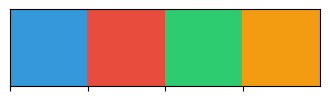

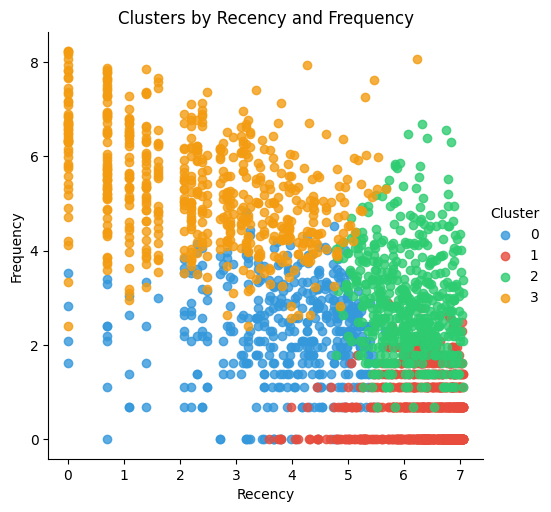

In [26]:
# Visualize the clusters using a lmplot
customPallete = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]
sns.set_palette(customPallete)
sns.palplot(customPallete)

data = pd.DataFrame(data=rfm_fig, columns=['CustomerID','Recency', 'Frequency', 'Monetary','Cluster'])

facet = sns.lmplot(data=data, x='Recency', y='Frequency', hue='Cluster', fit_reg=False)
plt.title('Clusters by Recency and Frequency')


Text(0.5, 1.0, 'Clusters by Frequency and Monetary')

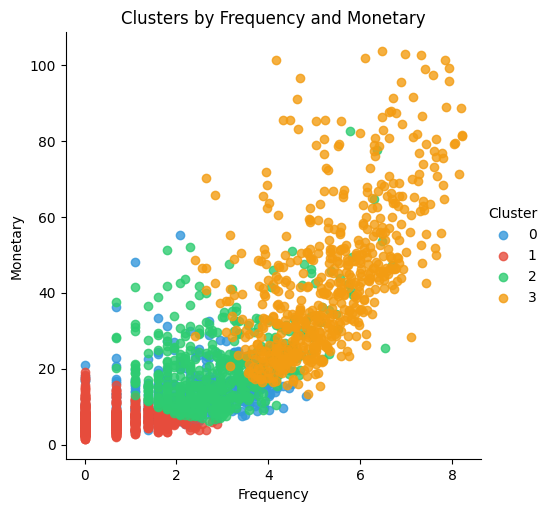

In [27]:
facet = sns.lmplot(data=data, x='Frequency',y='Monetary', hue='Cluster', fit_reg=False)
plt.title('Clusters by Frequency and Monetary')

3D plot to visualize the clusters

In [28]:
rfm['Cluster'] = rfm['Cluster'].astype('str')
fig = px.scatter_3d(rfm_fig, x='Recency', y='Frequency', z='Monetary', color='Cluster', opacity=0.7, width=800, height=800)
fig.show()

Rscore and FMScore function take in the value to be scored *x*, the column name *p* and *d* the quantiles dictionary.

In [29]:
numerical_features = rfm[['Recency', 'Frequency', 'Monetary']]
quantiles = numerical_features.quantile(q=[0.2,0.4,0.6,0.8])
quantiles = quantiles.to_dict()


'''
Recency Score.
Assigns Scores based on the quantile levels.
Customers who have purchased more recently get a higher score.
'''
def RScore(x,p,d):
    if x <= d[p][0.2]:
        return 5
    elif x <= d[p][0.4]:
        return 4
    elif x <= d[p][0.6]: 
        return 3
    elif x <= d[p][0.8]: 
        return 2
    else:
        return 1   
    
'''
Frequency and Monetary Score.
Assigns Scores based on the quantile levels but in reverse.
'''
def FMScore(x,p,d):
    if x <= d[p][0.2]:
        return 1
    elif x <= d[p][0.4]:
        return 2
    elif x <= d[p][0.6]: 
        return 3
    elif x <= d[p][0.8]: 
        return 4
    else:
        return 5
    
rfm['R'] = rfm['Recency'].apply(RScore, args=('Recency',quantiles,))
rfm['F'] = rfm['Frequency'].apply(FMScore, args=('Frequency',quantiles,))
rfm['M'] = rfm['Monetary'].apply(FMScore, args=('Monetary',quantiles,))
rfm['RFM_Score'] = rfm[['R','F','M']].sum(axis=1)

Assign buckets based on the RFM Scores

In [30]:
def assign_bucket(rfm_score):
    if rfm_score > 12:
        return 'Platinum'
    elif rfm_score <= 12 and rfm_score > 9:
        return 'Gold'
    elif rfm_score <= 9 and rfm_score > 6:
        return 'Silver'
    elif rfm_score <= 6 and rfm_score > 3:
        return 'Bronze'
    else:
        return 'Silicone'

buckets = ['Platinum', 'Gold', 'Silver', 'Bronze', 'Silicone']
rfm['Segments'] = rfm['RFM_Score'].apply(assign_bucket)
rfm.head()

,Recency,Frequency,Monetary,Cluster,R,F,M,RFM_Score,Segments
CustomerCode,,,,,,,,,
12346,92,3,7535.10,0,4,2,4,10,Gold
12347,537,2,3017.45,1,2,1,3,6,Bronze
12348,9,102,755281.56,3,5,4,5,14,Platinum
12350,12,300,38223.76,3,5,5,5,15,Platinum
12352,2,78,9454.96,3,5,4,4,13,Platinum
